# Exercício:

In [36]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [37]:
df_freqs_16 = pd.read_csv("frequencias_aminoacidos.csv")
print(df_freqs_16.head())


      M     K     V    T    G      L    A     F    C      R  ...     Q     I  \
0  14.0  27.0  50.0   36   47   69.0   76  21.0    7   47.0  ...  42.0  18.0   
1   9.0  26.0  50.0   50   66  103.0  109  46.0   17  113.0  ...  43.0  17.0   
2   2.0  12.0  17.0   20   51   19.0   44   8.0    6   30.0  ...  15.0   8.0   
3   0.0   0.0   0.0  143  151    0.0  112   0.0  155    0.0  ...   0.0   0.0   
4   2.0  10.0  11.0    2    1   13.0    7   3.0    5    6.0  ...   3.0   4.0   

      P     D     N     H    W  Sigla  Valina   Média_AA  
0  54.0  20.0  18.0  13.0  5.0  ROP16    50.0  36.047619  
1  73.0  52.0  17.0  25.0  2.0  ROP18    50.0  50.857143  
2  22.0  20.0   5.0   8.0  3.0   GRA7    17.0  18.761905  
3   0.0   0.0   0.0   0.0  0.0   SAG2     0.0  26.714286  
4   4.0   2.0   8.0   2.0  1.0    IL6    11.0   4.952381  

[5 rows x 23 columns]


In [38]:
def tendencia_central(obj):
    media = obj.mean()
    mediana = obj.median()
    moda = obj.mode()[0]
    return media, mediana, moda

media, mediana, moda = tendencia_central(df_freqs_16["S"])
print("Serina - Média:", media, "Mediana:", mediana, "Moda:", moda)

media3, mediana3, moda3 = tendencia_central(df_freqs_16.loc[2, ["S"]])
print("Serina no 3º gene - Média:", media3, "Mediana:", mediana3, "Moda:", moda3)

Serina - Média: 49.0 Mediana: 37.0 Moda: 0.0
Serina no 3º gene - Média: 37.0 Mediana: 37.0 Moda: 37.0


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [39]:
def amplitude(obj):
    return obj.max() - obj.min()

print("Amplitude da Isoleucina:", amplitude(df_freqs_16["I"]))

print("Amplitude do último gene:", amplitude(df_freqs_16.drop(columns=["Sigla"]).iloc[-1]))



Amplitude da Isoleucina: 18.0
Amplitude do último gene: 12.0


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [40]:
def quartis(obj):
    q1 = obj.quantile(0.25)
    q2 = obj.quantile(0.50)
    q3 = obj.quantile(0.75)
    return q1, q2, q3

print("Quartis da Metionina:", quartis(df_freqs_16["M"]))

print("Quartis do 1º gene:", quartis(df_freqs_16.drop(columns=["Sigla"]).iloc[0]))


Quartis da Metionina: (np.float64(2.0), np.float64(2.0), np.float64(9.0))
Quartis do 1º gene: (np.float64(18.0), np.float64(36.023809523809526), np.float64(49.25))


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

IQR do Ácido Glutâmico: 45.0
IQR do penúltimo gene: 0.0


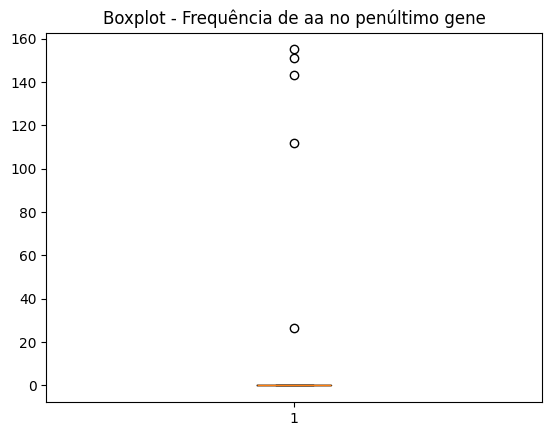

In [41]:
import matplotlib.pyplot as plt

def intervalo_interquartil(obj):
    q1 = obj.quantile(0.25)
    q3 = obj.quantile(0.75)
    return q3 - q1

print("IQR do Ácido Glutâmico:", intervalo_interquartil(df_freqs_16["E"]))

penultimo = df_freqs_16.drop(columns=["Sigla"]).iloc[-2]
print("IQR do penúltimo gene:", intervalo_interquartil(penultimo))

plt.boxplot(penultimo)
plt.title("Boxplot - Frequência de aa no penúltimo gene")
plt.show()


## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [42]:
def variancia(obj):
    return obj.var(ddof=1)  

print("Variância da Prolina:", variancia(df_freqs_16["P"]))

print("Variância do 3º gene:", variancia(df_freqs_16.drop(columns=["Sigla"]).iloc[2]))


Variância da Prolina: 1015.8
Variância do 3º gene: 218.08616780045355


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [43]:
def desvio_padrao(obj):
    return obj.std(ddof=1)

print("Desvio padrão do Triptofano:", desvio_padrao(df_freqs_16["W"]))

print("Desvio padrão do último gene:", desvio_padrao(df_freqs_16.drop(columns=["Sigla"]).iloc[-1]))


Desvio padrão do Triptofano: 1.9235384061671346
Desvio padrão do último gene: 3.565391723301883


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [44]:
def coef_var(obj):
    return obj.std(ddof=1) / obj.mean()

print("CV da Leucina:", coef_var(df_freqs_16["L"]))

print("CV do gene 1:", coef_var(df_freqs_16.drop(columns=["Sigla"]).iloc[1]))


CV da Leucina: 1.0667256868043067
CV do gene 1: 0.7037250367323811


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [45]:
def medidas_resumo(obj):
    resumo = {
        "Mínimo": obj.min(),
        "Q1": obj.quantile(0.25),
        "Mediana": obj.median(),
        "Q3": obj.quantile(0.75),
        "Máximo": obj.max(),
        "Média": obj.mean(),
        "Variância": obj.var(ddof=1),
        "Desvio Padrão": obj.std(ddof=1),
        "CV": coef_var(obj)
    }
    return resumo

print("Resumo da Metionina:", medidas_resumo(df_freqs_16["M"]))

Resumo da Metionina: {'Mínimo': np.float64(0.0), 'Q1': np.float64(2.0), 'Mediana': np.float64(2.0), 'Q3': np.float64(9.0), 'Máximo': np.float64(14.0), 'Média': np.float64(5.4), 'Variância': np.float64(34.8), 'Desvio Padrão': np.float64(5.89915248150105), 'CV': np.float64(1.0924356447224166)}


## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

Gene com maior CV: SAG2


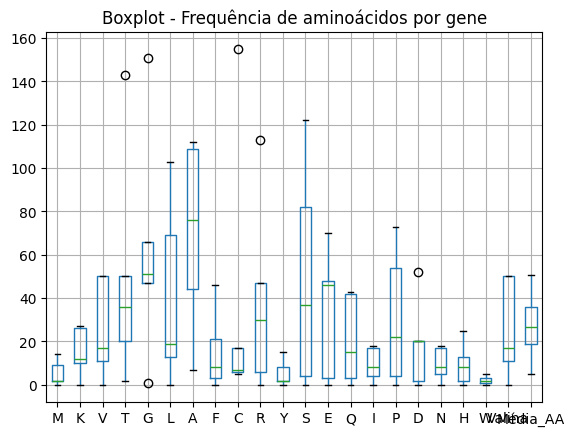

In [46]:
df_freqs_16["CV_gene"] = df_freqs_16.drop(columns=["Sigla"]).apply(coef_var, axis=1)
gene_maior_cv = df_freqs_16.loc[df_freqs_16["CV_gene"].idxmax()]
print("Gene com maior CV:", gene_maior_cv["Sigla"])

df_freqs_16.drop(columns=["Sigla", "CV_gene"]).boxplot()
plt.title("Boxplot - Frequência de aminoácidos por gene")
plt.show()


## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

Aminoácido com maior CV: C


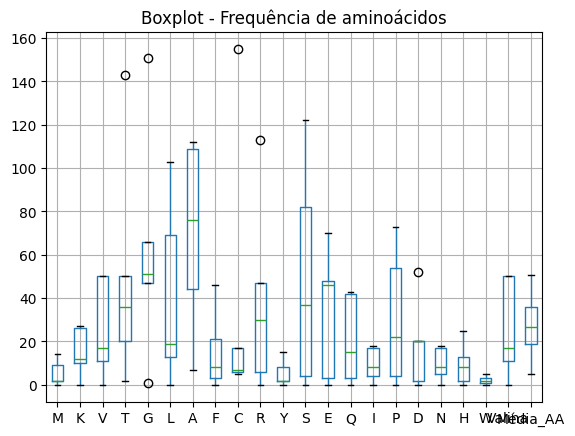

In [47]:
cv_aminoacidos = df_freqs_16.drop(columns=["Sigla", "CV_gene"]).apply(coef_var, axis=0)
aa_maior_cv = cv_aminoacidos.idxmax()
print("Aminoácido com maior CV:", aa_maior_cv)

df_freqs_16.drop(columns=["Sigla", "CV_gene"]).boxplot()
plt.title("Boxplot - Frequência de aminoácidos")
plt.show()
